In [1]:
%cd ..

c:\Users\user\OneDrive\Desktop\170A-CHOC


In [2]:
from data.data_partitioner import DataPartitioner

In [3]:
data = DataPartitioner(data_dir='data')
data.load_datasets()

In [4]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

In [35]:
df = data.choc
df_test = data.choc_svi[df.columns.tolist()]
df_eval = data.choc_svi_coi[df.columns.tolist()]

KeyError: "['leaf_id'] not in index"

In [6]:
# Convert categorical feature columns into dummy variables
df_enc = pd.get_dummies(df)
df_test_enc = pd.get_dummies(df_test)
df_eval_enc = pd.get_dummies(df_eval)

In [7]:
# Assuming 'df' is your DataFrame and 'target' is the column you want to predict
X_train = df_enc.drop(['no_show_Yes','no_show_No', 'NOSHOWS_365'], axis=1)
y_train = df_enc['no_show_Yes']
X_test = df_test_enc.drop(['no_show_Yes','no_show_No', 'NOSHOWS_365'], axis=1)
y_test = df_test_enc['no_show_Yes']
X_eval =  df_eval_enc.drop(['no_show_Yes','no_show_No', 'NOSHOWS_365'], axis=1)
y_eval = df_eval_enc['no_show_Yes']

In [8]:
# Initialize the classifier
clf = DecisionTreeClassifier(
    max_depth=2,           # The tree grows until all leaves are pure
    min_samples_split=200,      # The minimum samples required to split a node
    min_samples_leaf=100,       # The minimum samples allowed in a leaf
    max_leaf_nodes=None,       # Unlimited number of leaf nodes
    criterion='gini',
    random_state=42)

# Train the model
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,200
,min_samples_leaf,100
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


              precision    recall  f1-score   support

       False       0.88      1.00      0.94     27089
        True       0.89      0.07      0.13      3888

    accuracy                           0.88     30977
   macro avg       0.89      0.53      0.53     30977
weighted avg       0.88      0.88      0.84     30977



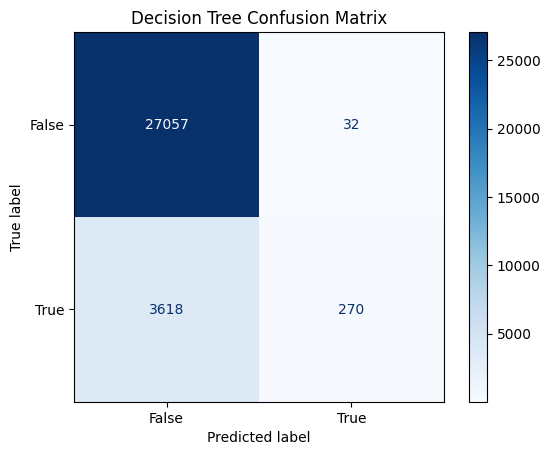

In [9]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred=clf.predict(X_train)
print(classification_report(y_train, y_pred))
# 2. Compute the confusion matrix
cm = confusion_matrix(y_train, y_pred)

# 3. Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Decision Tree Confusion Matrix")
plt.show()

              precision    recall  f1-score   support

       False       0.90      1.00      0.95     60672
        True       0.87      0.08      0.15      7519

    accuracy                           0.90     68191
   macro avg       0.89      0.54      0.55     68191
weighted avg       0.90      0.90      0.86     68191



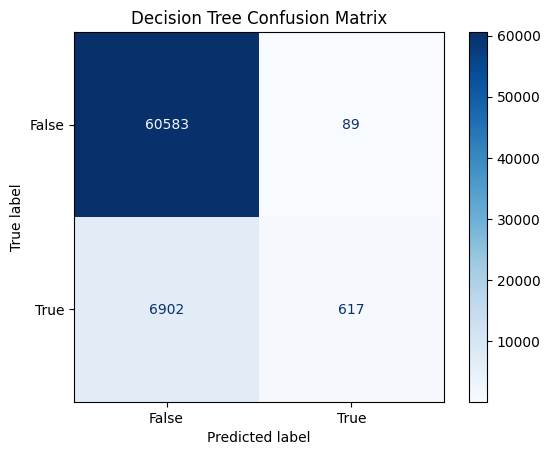

In [10]:
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
# 2. Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Decision Tree Confusion Matrix")
plt.show()

              precision    recall  f1-score   support

       False       0.88      1.00      0.94    401736
        True       0.86      0.04      0.08     57649

    accuracy                           0.88    459385
   macro avg       0.87      0.52      0.51    459385
weighted avg       0.88      0.88      0.83    459385



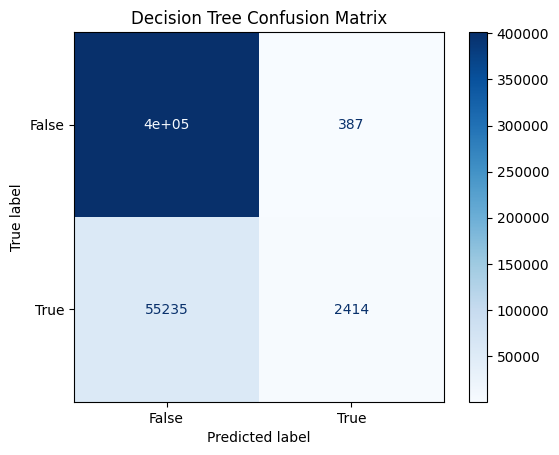

In [11]:
y_pred=clf.predict(X_eval)
print(classification_report(y_eval, y_pred))
# 2. Compute the confusion matrix
cm = confusion_matrix(y_eval, y_pred)

# 3. Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [12]:
from sklearn.tree import export_text

# show_weights=True adds the counts for each class
rules = export_text(clf, feature_names=list(X_train.columns), show_weights=True)
print(rules)

|--- INSURANCE_TYPE_Other/Unknown <= 0.50
|   |--- INSURANCE_TYPE_Commercial <= 0.50
|   |   |--- weights: [11038.00, 2047.00] class: False
|   |--- INSURANCE_TYPE_Commercial >  0.50
|   |   |--- weights: [15914.00, 1483.00] class: False
|--- INSURANCE_TYPE_Other/Unknown >  0.50
|   |--- PRIMARY_CARE_365 <= 0.50
|   |   |--- weights: [105.00, 88.00] class: False
|   |--- PRIMARY_CARE_365 >  0.50
|   |   |--- weights: [32.00, 270.00] class: True



In [20]:
# Assuming your column name is 'noshow' and values are 'Yes'/'No'
summary_df = df.pivot_table(
    index=['age', 
           'GENDER', 
           'RACE', 
           'ETHNICITY',
           'MOBILITY_ABILITY_DX_IND',
           'MENTAL_HEALTH_DX_IND',
           ], 
    columns='no_show', 
    aggfunc='size', 
    fill_value=0
).reset_index()

# Rename columns for clarity
summary_df.columns.name = None
summary_df = summary_df.rename(columns={'No': 'indv_noshow_no', 'Yes': 'indv_noshow_yes'})

In [32]:
summary_df

,age,GENDER,RACE,ETHNICITY,MOBILITY_ABILITY_DX_IND,MENTAL_HEALTH_DX_IND,indv_noshow_no,indv_noshow_yes
0,0,Male,Asian,Not Hispanic or Latino,No,No,2,0
1,0,Male,Multiple,Not Hispanic or Latino,No,No,1,0
2,0,Male,White,Hispanic or Latino,No,No,2,0
3,0,Male,White,Hispanic or Latino,No,Yes,1,0
4,1,Female,American Indian or Alaska Native,Hispanic or Latino,No,No,1,0
...,...,...,...,...,...,...,...,...
1270,21,Male,White,Hispanic or Latino,No,No,2,0
1271,21,Male,White,Hispanic or Latino,No,Yes,1,0
1272,21,Male,White,Not Hispanic or Latino,No,No,6,1
1273,21,Male,White,Not Hispanic or Latino,No,Yes,7,1


In [21]:
summary_df.shape

(1275, 8)

In [25]:
# Assuming 'clf' is your trained DecisionTreeClassifier
# and 'X' is the feature set used for that tree
df['leaf_id'] = clf.apply(X_train)

In [26]:
# 1. Total count per leaf group
leaf_counts = df.groupby('leaf_id').size().rename('total_group_count')

# 2. Breakdown of shows vs no-shows per leaf
# Assuming 'noshow' column has values 'Yes' and 'No'
leaf_stats = df.groupby(['leaf_id', 'no_show']).size().unstack(fill_value=0)

# Rename columns for clarity
leaf_stats = leaf_stats.rename(columns={'No': 'group_show_count', 'Yes': 'group_noshow_count'})

In [34]:
df

,no_show,age,GENDER,RACE,ETHNICITY,APPT_WEEKDAY,APPT_DAY_PART,DURATION,BOOK_TO_APPT,APPT_SEQ,...,total_group_count_x,group_show_count_x,group_noshow_count_x,group_noshow_rate,total_group_count_y,group_show_count_y,group_noshow_count_y,total_group_count,group_show_count,group_noshow_count
0,No,5,Male,White,Not Hispanic or Latino,Tuesday,Morning,30,54,Unknown,...,17397,15914,1483,0.085245,17397,15914,1483,17397,15914,1483
1,No,6,Female,Asian,Other/Unknown,Thursday,Morning,15,369,Unknown,...,17397,15914,1483,0.085245,17397,15914,1483,17397,15914,1483
2,Yes,10,Male,Other,Hispanic or Latino,Wednesday,Morning,15,366,Unknown,...,13085,11038,2047,0.156439,13085,11038,2047,13085,11038,2047
3,No,7,Male,White,Other/Unknown,Friday,Afternoon,30,1,Unknown,...,13085,11038,2047,0.156439,13085,11038,2047,13085,11038,2047
4,No,18,Male,Asian,Not Hispanic or Latino,Friday,Afternoon,60,1,Unknown,...,13085,11038,2047,0.156439,13085,11038,2047,13085,11038,2047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30972,No,19,Female,Black or African American,Hispanic or Latino,Thursday,Afternoon,15,1,Unknown,...,13085,11038,2047,0.156439,13085,11038,2047,13085,11038,2047
30973,No,15,Female,White,Other/Unknown,Wednesday,Afternoon,15,0,Unknown,...,17397,15914,1483,0.085245,17397,15914,1483,17397,15914,1483
30974,No,4,Female,White,Not Hispanic or Latino,Thursday,Morning,15,0,Unknown,...,17397,15914,1483,0.085245,17397,15914,1483,17397,15914,1483
30975,No,10,Female,Asian,Not Hispanic or Latino,Thursday,Afternoon,15,1,Unknown,...,17397,15914,1483,0.085245,17397,15914,1483,17397,15914,1483


In [33]:
leaf_stats

no_show,group_show_count,group_noshow_count
leaf_id,,
2,11038,2047
3,15914,1483
5,105,88
6,32,270


In [27]:
# Join the total counts
df = df.merge(leaf_counts, on='leaf_id', how='left')

# Join the show/no-show breakdown
df = df.merge(leaf_stats, on='leaf_id', how='left')

# Optional: Calculate the probability/rate for that group
df['group_noshow_rate'] = df['group_noshow_count'] / df['total_group_count']

In [29]:
df_final = df.merge(summary_df, on= ['age', 
           'GENDER', 
           'RACE', 
           'ETHNICITY',
           'MOBILITY_ABILITY_DX_IND',
           'MENTAL_HEALTH_DX_IND',
           ], how='left')

In [30]:
df_final

,no_show,age,GENDER,RACE,ETHNICITY,APPT_WEEKDAY,APPT_DAY_PART,DURATION,BOOK_TO_APPT,APPT_SEQ,...,group_noshow_count_x,group_noshow_rate,total_group_count_y,group_show_count_y,group_noshow_count_y,total_group_count,group_show_count,group_noshow_count,indv_noshow_no,indv_noshow_yes
0,No,5,Male,White,Not Hispanic or Latino,Tuesday,Morning,30,54,Unknown,...,1483,0.085245,17397,15914,1483,17397,15914,1483,126,9
1,No,6,Female,Asian,Other/Unknown,Thursday,Morning,15,369,Unknown,...,1483,0.085245,17397,15914,1483,17397,15914,1483,2,0
2,Yes,10,Male,Other,Hispanic or Latino,Wednesday,Morning,15,366,Unknown,...,2047,0.156439,13085,11038,2047,13085,11038,2047,47,9
3,No,7,Male,White,Other/Unknown,Friday,Afternoon,30,1,Unknown,...,2047,0.156439,13085,11038,2047,13085,11038,2047,3,0
4,No,18,Male,Asian,Not Hispanic or Latino,Friday,Afternoon,60,1,Unknown,...,2047,0.156439,13085,11038,2047,13085,11038,2047,69,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30972,No,19,Female,Black or African American,Hispanic or Latino,Thursday,Afternoon,15,1,Unknown,...,2047,0.156439,13085,11038,2047,13085,11038,2047,8,4
30973,No,15,Female,White,Other/Unknown,Wednesday,Afternoon,15,0,Unknown,...,1483,0.085245,17397,15914,1483,17397,15914,1483,7,2
30974,No,4,Female,White,Not Hispanic or Latino,Thursday,Morning,15,0,Unknown,...,1483,0.085245,17397,15914,1483,17397,15914,1483,57,8
30975,No,10,Female,Asian,Not Hispanic or Latino,Thursday,Afternoon,15,1,Unknown,...,1483,0.085245,17397,15914,1483,17397,15914,1483,62,9


In [45]:
def feature_eng(df, summary_df, clf, leaf_stats,  X_eval):
    nndf = df.merge(summary_df, on= ['age', 
           'GENDER', 
           'RACE', 
           'ETHNICITY',
           'MOBILITY_ABILITY_DX_IND',
           'MENTAL_HEALTH_DX_IND',
           ], how='left')
    nndf['leaf_id'] = clf.apply(X_eval)
    nndf = nndf.merge(leaf_stats, on='leaf_id', how='left')
    return nndf.drop(columns=['leaf_id','age', 
           'GENDER', 
           'RACE', 
           'ETHNICITY',
           'MOBILITY_ABILITY_DX_IND',
           'MENTAL_HEALTH_DX_IND','INSURANCE_TYPE','PRIMARY_CARE_365'])

In [46]:
data.choc_svi_coi

,no_show,age,GENDER,RACE,ETHNICITY,APPT_WEEKDAY,APPT_DAY_PART,DURATION,BOOK_TO_APPT,APPT_SEQ,...,r_SE_nat,r_COI_nat,c5_ED_stt,c5_HE_stt,c5_SE_stt,c5_COI_stt,r_ED_stt,r_HE_stt,r_SE_stt,r_COI_stt
0,Yes,8,Male,Other,Hispanic or Latino,Wednesday,Evening,270,9,Unknown,...,37.0,38.0,Moderate,Low,Moderate,Moderate,54.0,39.0,44.0,46.0
1,No,4,Male,White,Hispanic or Latino,Tuesday,Afternoon,30,76,Unknown,...,47.0,36.0,Low,Low,Moderate,Moderate,25.0,22.0,54.0,43.0
2,No,16,Male,Multiple,Hispanic or Latino,Thursday,Evening,270,10,Unknown,...,91.0,83.0,High,Moderate,Very High,Very High,74.0,47.0,94.0,84.0
3,No,2,Female,White,Hispanic or Latino,Wednesday,Morning,60,321,Unknown,...,22.0,20.0,Low,Low,Low,Low,29.0,23.0,26.0,25.0
4,No,11,Female,Multiple,Other/Unknown,Monday,Afternoon,15,368,Unknown,...,71.0,86.0,Very High,High,High,Very High,94.0,68.0,78.0,86.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
459380,No,2,Female,Multiple,Hispanic or Latino,Thursday,Morning,20,0,Unknown,...,96.0,96.0,Very High,Moderate,Very High,Very High,92.0,51.0,98.0,95.0
459381,Yes,13,Female,White,Hispanic or Latino,Thursday,Afternoon,15,0,Unknown,...,62.0,69.0,High,Moderate,High,High,80.0,54.0,69.0,73.0
459382,Yes,15,Female,White,Hispanic or Latino,Thursday,Afternoon,30,0,Unknown,...,48.0,71.0,Very High,Moderate,Moderate,High,96.0,44.0,55.0,74.0
459383,No,14,Male,Other,Hispanic or Latino,Wednesday,Afternoon,5,0,Unknown,...,32.0,26.0,Very Low,Low,Low,Low,15.0,40.0,39.0,32.0


In [47]:
engineered_data = feature_eng(data.choc_svi_coi,summary_df,clf,leaf_stats, X_eval)

In [48]:
engineered_data

,no_show,APPT_WEEKDAY,APPT_DAY_PART,DURATION,BOOK_TO_APPT,APPT_SEQ,CANCELS_365,APPTS_365,NOSHOWS_365,RESCHEDS_365,...,c5_SE_stt,c5_COI_stt,r_ED_stt,r_HE_stt,r_SE_stt,r_COI_stt,indv_noshow_no,indv_noshow_yes,group_show_count,group_noshow_count
0,Yes,Wednesday,Evening,270,9,Unknown,0,3,2,0,...,Moderate,Moderate,54.0,39.0,44.0,46.0,55.0,7.0,11038,2047
1,No,Tuesday,Afternoon,30,76,Unknown,2,4,0,0,...,Moderate,Moderate,25.0,22.0,54.0,43.0,61.0,11.0,15914,1483
2,No,Thursday,Evening,270,10,Unknown,0,8,0,0,...,Very High,Very High,74.0,47.0,94.0,84.0,7.0,2.0,11038,2047
3,No,Wednesday,Morning,60,321,Unknown,0,8,0,0,...,Low,Low,29.0,23.0,26.0,25.0,27.0,0.0,11038,2047
4,No,Monday,Afternoon,15,368,Unknown,0,2,0,1,...,High,Very High,94.0,68.0,78.0,86.0,7.0,2.0,15914,1483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
459380,No,Thursday,Morning,20,0,Unknown,1,3,0,1,...,Very High,Very High,92.0,51.0,98.0,95.0,22.0,1.0,15914,1483
459381,Yes,Thursday,Afternoon,15,0,Unknown,1,3,1,1,...,High,High,80.0,54.0,69.0,73.0,66.0,10.0,15914,1483
459382,Yes,Thursday,Afternoon,30,0,Unknown,1,36,3,11,...,Moderate,High,96.0,44.0,55.0,74.0,95.0,18.0,11038,2047
459383,No,Wednesday,Afternoon,5,0,Unknown,9,51,5,13,...,Low,Low,15.0,40.0,39.0,32.0,76.0,7.0,11038,2047


In [50]:
engineered_data.to_csv('data/no_beta_engineered_data.csv')